# Predicted vs Real Profiles — Several Process Executions

Loads the saved curve arrays (`predicted_curves.parquet`, written when a run has
`save_predicted_curves: True` in `pipeline.py`) directly from disk — no retraining,
these are the actual production models' outputs. For a chosen process and a handful of
sensors, plots the real complete-case profile against every approach available for that
sensor, for several real test cases ("process executions"):

- **Real** — the case's actual sensor readings.
- **Best, mine** — full process simulation (best-fidelity mode) + DTW + Ext. Factors +
  Prev. Activity curve prediction.
- **Schedule-direct** — case-level regression from schedule-only features, no simulation.
- **Stochastic generator** — per-position Normal fit, no conditioning at all.

Source: `schedule_profile_eval_results/<process>/predicted_curves.parquet` (requires the
pipeline run to have `run_schedule_profile_eval: True` and `save_predicted_curves: True`).


90 cases available (case: real length in min) -- set CASES to pick:
   batch_294: 72          batch_221: 75          batch_230: 81          batch_238: 83          batch_295: 84          batch_216: 85       
   batch_229: 85          batch_212: 85          batch_268: 86          batch_297: 88          batch_267: 89          batch_236: 90       
   batch_223: 91          batch_300: 92          batch_280: 94          batch_287: 95          batch_264: 96          batch_290: 96       
   batch_244: 96          batch_260: 98          batch_254: 98          batch_250: 100         batch_279: 100         batch_226: 101      
   batch_225: 102         batch_269: 103         batch_253: 103         batch_218: 105         batch_249: 105         batch_242: 105      
   batch_217: 106         batch_278: 107         batch_234: 109         batch_276: 110         batch_258: 110         batch_270: 111      
   batch_274: 112         batch_227: 113         batch_285: 114         batch_248: 115         batch_286: 116         batch_233: 116      
   batch_282: 116         batch_261: 117         batch_257: 117         batch_246: 117         batch_228: 118         batch_220: 120      
   batch_265: 120         batch_292: 121         batch_213: 121         batch_256: 122         batch_231: 124         batch_245: 125      
   batch_224: 127         batch_214: 127         batch_271: 129         batch_262: 130         batch_232: 131         batch_272: 131      
   batch_241: 131         batch_251: 132         batch_283: 133         batch_247: 133         batch_273: 136         batch_235: 136      
   batch_237: 140         batch_252: 141         batch_243: 142         batch_259: 144         batch_211: 144         batch_296: 146      
   batch_219: 147         batch_275: 150         batch_299: 150         batch_298: 153         batch_288: 156         batch_284: 158      
   batch_255: 159         batch_215: 159         batch_266: 159         batch_291: 161         batch_239: 165         batch_263: 168      
   batch_240: 173         batch_222: 183         batch_289: 188         batch_281: 189         batch_277: 239         batch_293: 239

In [ ]:
# -- Config --------------------------------------------------------------------
PROCESS = 'process_1'
N_CASES = 4          # how many real test cases to show per sensor
#CASES   = ['batch_274', 'batch_261', 'batch_220']      # None = pick automatically (see CASE_PICK); or name them
                     # explicitly, e.g. ['batch_211', 'batch_240', 'batch_263']
                     # The full list of available cases is printed below.
CASE_PICK = 'spread' # 'spread' = shortest / longest and evenly spaced in between
                     # 'random' = random sample driven by RANDOM_STATE
SENSORS = None       # None = auto-pick; or set explicitly, e.g. ['destillation_steam_demand_kW_energy_to_model']
EXCLUDE_SENSORS = ['bottling_power_kW_energy_to_model']   # dropped from the figures
RANDOM_STATE = 42

# -- Which run to read ---------------------------------------------------------
# None = latest run that has the curves this notebook needs (previous behaviour).
# Otherwise the run to use, by full directory name or by any substring of it:
#   RUN = 'experiment_964'                      -> latest run matching that
#   RUN = 'experiment_964_20260723_190547'      -> exactly that run
RUN = None

# -- Which series to draw, in this order (legend, drawing and strip order) ----
#   Best Net + Budget -- best discovered net + total-duration budgeting
#   Best Net          -- best discovered net
#   Alpha             -- naive alpha-miner net
#   Schedule-direct   -- case-level regression from schedule features, no simulation
#   Profile-generator -- stochastic per-position generator, no conditioning
SERIES_TO_SHOW = ['Real', 'Best Net + Budget', 'Best Net', 'Alpha',
                  'Schedule-direct', 'Profile-generator']

# The mean panel next to each curve: 'case' divides the curve's integral by the
# FULL case span (a predicted curve that only covers the autoclave window counts
# as 0 elsewhere, so the means are comparable across methods); 'curve' divides by
# each curve's own span, which rewards methods that simply predict less.
MEAN_OVER = 'case'       # 'case' | 'curve'

PLOT_STYLE = 'overlay'   # 'overlay' = all methods in one axes (+ activity strips)
                         # 'facet'   = one small panel per method, real greyed behind

# -- How the nets are chosen ---------------------------------------------------
# This notebook only VISUALIZES, it reports no numbers, so picking the model on
# TEST is fine here -- it shows what the best model actually does on the cases
# being plotted. Set SELECT_ON = 'train' to show exactly the models the tables
# in results_process.ipynb / the paper are selected on.
SELECT_ON = 'test'       # 'test' | 'train' -- split used to pick Best Net + time variant
TIME_PRED = 'best'       # 'best' = lowest <SELECT_ON>_overall_error per net,
                         # or fix it: 'baseline' | 'ml_global' | 'ml_local'
CURVE_APPROACH      = 'ml_external'   # curve predictor for the three nets
DISABLED_MINERS = ['wip_aware', 'wip_branching_aware']

# The curve-approach FILE NAME differs between runs: the approach now called
# 'ml_external' was written as 'ml_exog_prev_activity' before the rename (same
# method, same features -- only the key changed), and likewise for the seq2seq
# variant. Every run older than the rename therefore carries the old file name,
# and asking for 'ml_external' alone finds nothing there. The loader below tries
# each alias in order and uses the first that exists on disk; add a pair here if
# an approach is renamed again.
CURVE_APPROACH_ALIASES = {
    'ml_external':      ['ml_external', 'ml_exog_prev_activity'],
    'seq2seq_external': ['seq2seq_external', 'seq2seq_prev_activity'],
}

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)

results_root = Path('..') / 'results'

# Runs that actually have the schedule curves this notebook starts from.
_candidates = [d for d in sorted(results_root.iterdir())
               if d.is_dir()
               and (d / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet').exists()]
assert _candidates, f'No run found with schedule_profile_eval_results/{PROCESS}/predicted_curves.parquet'

if RUN:
    # Explicit pick: exact directory name, or any substring of it (latest match).
    _matches = [d for d in _candidates if d.name == RUN] or \
               [d for d in _candidates if RUN in d.name]
    if not _matches:
        raise AssertionError(
            f'RUN={RUN!r} matches no run with curves for {PROCESS}.\n'
            f'Available: ' + ', '.join(d.name for d in _candidates))
    run_dir = _matches[-1]
else:
    run_dir = _candidates[-1]
print(f'Using run: {run_dir.name}' + ('' if RUN else '   (latest; set RUN to pin one)'))

curves_path = run_dir / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet'
df_curves = pd.read_parquet(curves_path)
print(f'{len(df_curves)} rows | sensors: {sorted(df_curves["sensor"].unique())} | '
      f'{df_curves["case_id"].nunique()} cases | series: {sorted(df_curves["series"].unique())}')

In [ ]:
# -- Add the simulated series to df_curves ------------------------------------
# All curve files share the (case_id, sensor, t_minutes) convention -- minutes
# since that curve's own case start -- so they drop straight into df_curves.
# The three nets differ ONLY in the net, so they are directly comparable.
_TIME_SUFFIX = {'baseline': '', 'ml_global': '_ml_plus_global', 'ml_local': '_ml_plus_per_act'}

# Candidate file names for the requested curve approach, in preference order
# (see CURVE_APPROACH_ALIASES: the same method was written under a different
# name before the rename, so a run older than it carries the old file).
_approach_names = (['']
                   if CURVE_APPROACH in ('baseline', '', None)
                   else CURVE_APPROACH_ALIASES.get(CURVE_APPROACH, [CURVE_APPROACH]))

def _curve_file(mode_dir):
    """First existing predicted_curves file for CURVE_APPROACH in mode_dir."""
    for _name in _approach_names:
        p = mode_dir / (f'predicted_curves_{_name}.parquet' if _name else 'predicted_curves.parquet')
        if p.exists():
            return p
    return None

_pe_all = pd.read_parquet(run_dir / 'process_eval_results.parquet')
def _parse_mode(m):
    r = str(m)[len('petri_net_'):] if str(m).startswith('petri_net_') else str(m)
    for suf, tp in (('_ml_plus_global', 'ml_global'), ('_ml_plus_per_act', 'ml_local')):
        if r.endswith(suf):
            return r[:-len(suf)], tp
    return r, 'baseline'
_pe_all['model'], _pe_all['time_pred'] = zip(*_pe_all['mode'].map(_parse_mode))
_pe_proc = _pe_all[(_pe_all['process'] == PROCESS) & (~_pe_all['model'].isin(DISABLED_MINERS))]

# Best Net = miner with the best average of the four discovery metrics on SELECT_ON.
_sel_cols = [f'{SELECT_ON}_conformance_metrics_{m}' for m in
             ('fitness', 'precision', 'generalization', 'simplicity')]
_sel_cols = [c for c in _sel_cols if c in _pe_proc.columns]
_cands = sorted(set(_pe_proc['model'].unique()) - {'alpha', 'budget'})
_gc = _pe_proc[_pe_proc['model'].isin(_cands)]
best_miner = (_gc.groupby('model')[_sel_cols].mean().mean(axis=1).idxmax()
              if _sel_cols and not _gc.empty else None)
print(f'Best Net for {PROCESS}: {best_miner}   (candidates: {_cands}, selected on {SELECT_ON.upper()})')

# Time-prediction variant per net: fixed, or the one with the lowest overall error.
_err_col = f'{SELECT_ON}_overall_error'
def _time_pred_for(model):
    if TIME_PRED != 'best':
        return TIME_PRED
    g = _pe_proc[(_pe_proc['model'] == model)].dropna(subset=[_err_col])
    return g.sort_values(_err_col).iloc[0]['time_pred'] if not g.empty else 'baseline'

NET_MODES = {}   # display label -> full mode directory name
for _label, _model in (('Best Net + Budget', 'budget'),
                       ('Best Net',          best_miner),
                       ('Alpha',             'alpha')):
    if _model:
        _tp = _time_pred_for(_model)
        NET_MODES[_label] = f'petri_net_{_model}{_TIME_SUFFIX[_tp]}'
        print(f'  {_label:<18} -> {NET_MODES[_label]}   (time variant: {_tp})')

_extra_frames = []
def _add(label, mode_dir):
    if not mode_dir.exists():
        print(f'  {label:<18} MISSING mode dir {mode_dir.name} -- skipped'); return
    path = _curve_file(mode_dir)
    if path is None:
        _have = sorted(p.name for p in mode_dir.glob('predicted_curves*.parquet'))
        print(f'  {label:<18} NO FILE for CURVE_APPROACH={CURVE_APPROACH!r} '
              f'(tried: {_approach_names}) in {mode_dir.name}\n'
              f'{"":<22}available here: {_have}')
        return
    d = pd.read_parquet(path)
    d = d[d['series'] == 'predicted'].copy()
    d['series'] = label
    _extra_frames.append(d[['case_id', 'sensor', 'series', 't_minutes', 'value']])
    print(f'  {label:<18} <- {path.parent.name}/{path.name}: {len(d):,} rows, '
          f'{d["case_id"].nunique()} cases, {d["sensor"].nunique()} sensors')

_cc = run_dir / 'complete_curve_eval_results' / PROCESS
for _label, _mode in NET_MODES.items():
    _add(_label, _cc / _mode)

# The schedule parquet already holds Schedule-direct and the stochastic generator.
df_curves['series'] = df_curves['series'].replace(
    {'real': 'Real', 'schedule': 'Schedule-direct', 'stochastic': 'Profile-generator'})
df_curves = df_curves[~df_curves['series'].isin(list(NET_MODES))]
if _extra_frames:
    df_curves = pd.concat([df_curves] + _extra_frames, ignore_index=True)
else:
    print('\n!! no net curves loaded -- the figures will show only Real / Schedule-direct / '
          'Profile-generator. Check CURVE_APPROACH against the files listed above.')
print('\nseries now in df_curves:', sorted(df_curves['series'].unique()))

In [169]:
CASES   = ['batch_241', 'batch_261', 'batch_220'] 

In [170]:
# -- Pick sensors and cases to show --
# A sensor qualifies on Real + the nets; the optional series (Schedule-direct,
# Profile-generator) are reported when missing, not required.
_needed = {'Real'} | (set(NET_MODES) & set(SERIES_TO_SHOW))
_optional = [s for s in SERIES_TO_SHOW if s not in _needed]
_series_by_sensor = df_curves.groupby('sensor')['series'].apply(set)
if SENSORS is None:
    _full = [s for s, ser in _series_by_sensor.items() if _needed <= ser]
    SENSORS = _full if _full else sorted(df_curves['sensor'].unique())
SENSORS = [s for s in SENSORS if s not in EXCLUDE_SENSORS]
print(f'Sensors to show ({len(SENSORS)}):')
for s in SENSORS:
    _missing = [x for x in SERIES_TO_SHOW if x not in _series_by_sensor.get(s, set())]
    print(f'  [{s}]' + (f'  missing: {_missing}' if _missing else ''))

# -- Which cases are available, and which ones get plotted --------------------
# Length = span of the REAL curve, i.e. how long that execution actually ran.
_len = (df_curves[df_curves['series'] == 'Real']
        .groupby('case_id')['t_minutes'].max().sort_values())
print(f'\n{len(_len)} cases available (case: real length in min) -- set CASES to pick:')
_items = [f'{c}: {v:.0f}' for c, v in _len.items()]
for i in range(0, len(_items), 6):
    print('   ' + '   '.join(f'{x:<20}' for x in _items[i:i + 6]))

if CASES:
    example_cases = [c for c in CASES if c in set(_len.index)]
    _unknown = [c for c in CASES if c not in set(_len.index)]
    if _unknown:
        print(f'!! not in this run, ignored: {_unknown}')
elif CASE_PICK == 'spread':
    # shortest, longest and evenly spaced in between -- shows the range of
    # executions instead of whatever the seed happened to draw.
    _idx = np.linspace(0, len(_len) - 1, min(N_CASES, len(_len))).round().astype(int)
    example_cases = [_len.index[i] for i in dict.fromkeys(_idx)]
else:
    rng = np.random.default_rng(RANDOM_STATE)
    example_cases = list(rng.choice(sorted(_len.index), size=min(N_CASES, len(_len)),
                                    replace=False))
print(f'\nPlotting cases: {[(c, f"{_len[c]:.0f} min") for c in example_cases]}')


Sensors to show (5):
  [autoclave_cooling_water_demand_kW_energy_to_model]
  [autoclave_steam_demand_kW_energy_to_model]
  [destillation_cooling_demand_kW_energy_to_model]
  [destillation_steam_demand_kW_energy_to_model]
  [individual_packaging_power_kW_energy_to_model]

90 cases available (case: real length in min) -- set CASES to pick:
   batch_294: 72          batch_221: 75          batch_230: 81          batch_238: 83          batch_295: 84          batch_216: 85       
   batch_229: 85          batch_212: 85          batch_268: 86          batch_297: 88          batch_267: 89          batch_236: 90       
   batch_223: 91          batch_300: 92          batch_280: 94          batch_287: 95          batch_264: 96          batch_290: 96       
   batch_244: 96          batch_260: 98          batch_254: 98          batch_250: 100         batch_279: 100         batch_226: 101      
   batch_225: 102         batch_269: 103         batch_253: 103         batch_218: 105         batch_249

In [171]:
from matplotlib.lines import Line2D

# -- Load the real activity log and one simulated log per net -----------------
# Each net writes its own simulated log under predicted_logs/, named after the
# same mode directory its curves came from -- so the activity strip under a
# curve is exactly the schedule that produced that curve.
df_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')

sim_logs = {}
for _label, _mode in NET_MODES.items():
    _p = run_dir / 'predicted_logs' / f'{PROCESS}_{_mode}.parquet'
    if _p.exists():
        sim_logs[_label] = pd.read_parquet(_p)
        print(f'  {_label:<18} log <- {_p.name}')
    else:
        print(f'  {_label:<18} log MISSING ({_p.name}) -- no strip for it')


def _activity_timeline(df_log, case_id):
    """Per-case activity segments in minutes since THAT log's own case start
    (real log uses the real case start, each sim log uses its own simulated
    case start -- the same convention the curves themselves use)."""
    sub = df_log[df_log['case_id'] == case_id].copy()
    if sub.empty:
        return sub
    sub['timestamp_start'] = pd.to_datetime(sub['timestamp_start'])
    sub['timestamp_end']   = pd.to_datetime(sub['timestamp_end'])
    sub = sub.sort_values('timestamp_start')
    t0 = sub['timestamp_start'].min()
    sub['t_start_min'] = (sub['timestamp_start'] - t0).dt.total_seconds() / 60
    sub['t_end_min']   = (sub['timestamp_end']   - t0).dt.total_seconds() / 60
    cols = ['activity', 'object', 't_start_min', 't_end_min']
    return sub[[c for c in cols if c in sub.columns]].reset_index(drop=True)


  Best Net + Budget  log <- process_1_petri_net_budget_ml_plus_per_act.parquet
  Best Net           log <- process_1_petri_net_heuristic_ml_plus_per_act.parquet
  Alpha              log <- process_1_petri_net_alpha_ml_plus_per_act.parquet


In [172]:
# import matplotlib.cm as cm
# from matplotlib.lines import Line2D

# # ── Style ────────────────────────────────────────────────────────────────────
# # Okabe-Ito palette (colour-blind safe). Real is the only black, heavy line and
# # is also filled, so it reads as the reference at a glance; the methods are thin
# # and coloured. Keep SERIES_TO_SHOW short -- three methods is already busy.
# _series_style = {
#     'Real':              dict(color='black',   linestyle='-',   linewidth=2.4, zorder=8),
#     'Best Net + Budget': dict(color='#009E73', linestyle='-',   linewidth=1.6, zorder=7),
#     'Best Net':          dict(color='#0072B2', linestyle='-',   linewidth=1.6, zorder=6),
#     'Alpha':             dict(color='#E69F00', linestyle='-',   linewidth=1.6, zorder=5),
#     'Schedule-direct':   dict(color='#CC79A7', linestyle='--',  linewidth=1.1, zorder=3),
#     'Profile-generator': dict(color='#999999', linestyle=':',   linewidth=1.0, zorder=2),
# }
# _REAL_FILL = '#0000000F'          # very light grey under the real curve

# def _curve_mean(s, case_span=None):
#     """Time-weighted mean kW of one curve. With case_span, the integral is
#     divided by the full case span instead of the curve's own -- gaps count as
#     zero, which is what makes the methods comparable (MEAN_OVER='case')."""
#     t, v = s['t_minutes'].to_numpy(), s['value'].to_numpy()
#     if len(t) < 2:
#         return float(v.mean()) if len(v) else 0.0
#     span = case_span if (MEAN_OVER == 'case' and case_span) else (t.max() - t.min())
#     return float(np.trapezoid(v, t) / span) if span > 0 else float(v.mean())


# def _draw_means(ax, sub, names):
#     """Small horizontal bar chart of each method's mean for this case, in the
#     same order and colours as the curves. Real sits on top as the reference."""
#     _span = float(sub['t_minutes'].max() - sub['t_minutes'].min())   # full case
#     vals, cols, labels = [], [], []
#     for name in names:
#         s = sub[sub['series'] == name].sort_values('t_minutes')
#         if s.empty:
#             continue
#         vals.append(_curve_mean(s, _span))
#         cols.append(_series_style[name]['color'])
#         labels.append(name)
#     ypos = range(len(vals))
#     ax.barh(list(ypos), vals, color=cols, edgecolor='white', linewidth=0.5, height=0.75)
#     _real = vals[labels.index('Real')] if 'Real' in labels else None
#     if _real is not None:
#         ax.axvline(_real, color='black', linewidth=0.8, linestyle=':', zorder=5)
#     for y, v in zip(ypos, vals):
#         ax.text(v, y, f' {v:,.0f}', va='center', ha='left', fontsize=6, clip_on=False)
#     ax.set_yticks([]); ax.invert_yaxis()
#     ax.set_xlim(0, max(vals) * 1.5 if vals else 1)
#     ax.tick_params(labelsize=6)
#     ax.set_title(f'mean kW\n(over {MEAN_OVER})', fontsize=7)
#     for side in ('top', 'right', 'left'):
#         ax.spines[side].set_visible(False)
#     ax.grid(axis='x', alpha=0.15, linewidth=0.6)


# def _draw_series(ax, sub, names, fill_real=True):
#     """Draw the requested series of one (sensor, case) onto ax. Returns the
#     handles actually drawn, so the legend only lists what is visible."""
#     drawn = []
#     for name in names:
#         s = sub[sub['series'] == name].sort_values('t_minutes')
#         if s.empty:
#             continue
#         if name == 'Real' and fill_real:
#             ax.fill_between(s['t_minutes'], s['value'], color='black', alpha=0.06, zorder=0)
#         ln, = ax.plot(s['t_minutes'], s['value'], label=name, **_series_style[name])
#         drawn.append(ln)
#     return drawn

# # ── Activity strips (unchanged behaviour, lighter labels) ───────────────────
# _activity_color_map = {}
# def _color_for_activity(act):
#     if act not in _activity_color_map:
#         _activity_color_map[act] = cm.tab20(len(_activity_color_map) % 20)
#     return _activity_color_map[act]

# def _draw_activity_strip(ax, timeline_df, fontsize=5):
#     """One bar per activity. A label is written horizontally inside its bar only
#     if it fits -- no rotated text, no overflowing text. Width is estimated from
#     the axes geometry (~0.6 em per character), so no renderer is needed."""
#     if timeline_df is None or timeline_df.empty:
#         ax.set_yticks([]); return
#     _lo, _hi = timeline_df['t_start_min'].min(), timeline_df['t_end_min'].max()
#     _span = max(_hi - _lo, 1e-9)
#     _ax_in = ax.figure.get_size_inches()[0] * ax.get_position().width
#     _char_in = fontsize * 0.6 / 72.0            # rough advance width per character
#     for _, row in timeline_df.iterrows():
#         width = row['t_end_min'] - row['t_start_min']
#         ax.barh(0, width, left=row['t_start_min'], height=1.0,
#                 color=_color_for_activity(row['activity']), edgecolor='white', linewidth=0.6)
#         label = str(row['activity'])
#         if width / _span * _ax_in >= 1.1 * _char_in * len(label):     # 10% margin
#             ax.text(row['t_start_min'] + width / 2, 0, label,
#                     ha='center', va='center', fontsize=fontsize, clip_on=True)
#     ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)


# def _clean(ax):
#     ax.grid(alpha=0.15, linewidth=0.6)
#     for side in ('top', 'right'):
#         ax.spines[side].set_visible(False)

# _methods = [s for s in SERIES_TO_SHOW if s != 'Real']

# # ── One figure per sensor ───────────────────────────────────────────────────
# for sensor in SENSORS:
#     sub_sensor = df_curves[df_curves['sensor'] == sensor]
#     _short = sensor.replace('_energy_to_model', '')

#     if PLOT_STYLE == 'facet':
#         # Small multiples: one row per method, one column per case. Each panel
#         # shows only that method against the real curve, so nothing overlaps.
#         nrow, ncol = len(_methods), len(example_cases)
#         fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 1.9 * nrow),
#                                  sharex='col', sharey='row', squeeze=False)
#         for j, cid in enumerate(example_cases):
#             sub = sub_sensor[sub_sensor['case_id'] == cid]
#             for i, m in enumerate(_methods):
#                 ax = axes[i][j]
#                 _draw_series(ax, sub, ['Real', m])
#                 _clean(ax)
#                 ax.tick_params(labelsize=7)
#                 if i == 0:
#                     ax.set_title(f'case {cid}', fontsize=9)
#                 if j == 0:
#                     ax.set_ylabel(m, fontsize=8)
#                 if i == nrow - 1:
#                     ax.set_xlabel('minutes since case start', fontsize=7)
#         fig.suptitle(f'{_short} — real (black) vs each method', fontsize=11, y=1.01)
#         fig.tight_layout()
#         plt.show()
#         continue

#     # ── Overlay: curve + one activity strip per log, one block per case ─────
#     # Strips: the real schedule first, then the schedule each net actually
#     # simulated -- so a curve that fires late can be read off its own strip.
#     _strips = ([('Real', df_real_log, 'black')]
#                + [(m, sim_logs[m], _series_style[m]['color'])
#                   for m in _methods if m in sim_logs])
#     _n = len(example_cases)
#     _height_ratios, _row_start = [], []
#     for i in range(_n):
#         _row_start.append(len(_height_ratios))
#         _height_ratios += [4] + [0.5] * len(_strips)   # strips: thin bands
#         if i < _n - 1:
#             _height_ratios.append(2.2)          # spacer: keeps the x-label off
#                                                 # the next case's title
#     fig = plt.figure(figsize=(12.6, (2.9 + 0.3 * len(_strips)) * _n))
#     # Column 0 = the per-case mean of every method, column 1 = the curves.
#     gs = fig.add_gridspec(len(_height_ratios), 2, height_ratios=_height_ratios,
#                           width_ratios=[1, 7], hspace=0.1, wspace=0.08)

#     _present = [s for s in SERIES_TO_SHOW if s in set(sub_sensor['series'])]
#     handles = [Line2D([0], [0], label=s, **_series_style[s]) for s in _present]
#     for i, cid in enumerate(example_cases):
#         r0 = _row_start[i]
#         ax_mean  = fig.add_subplot(gs[r0, 0])
#         ax_curve = fig.add_subplot(gs[r0, 1])
#         ax_strips = [fig.add_subplot(gs[r0 + 1 + k, 1], sharex=ax_curve)
#                      for k in range(len(_strips))]

#         sub = sub_sensor[sub_sensor['case_id'] == cid]
#         if sub.empty:
#             ax_curve.set_title(f'case {cid} — no data for this sensor', fontsize=9)
#             ax_mean.axis('off')
#         else:
#             _draw_series(ax_curve, sub, SERIES_TO_SHOW)
#             _draw_means(ax_mean, sub, SERIES_TO_SHOW)
#             ax_curve.set_title(f'case {cid}', fontsize=9)
#         ax_curve.set_ylabel('kW', fontsize=8)
#         _clean(ax_curve)
#         plt.setp(ax_curve.get_xticklabels(), visible=False)

#         for k, ((_lbl, _log, _col), ax_s) in enumerate(zip(_strips, ax_strips)):
#             _draw_activity_strip(ax_s, _activity_timeline(_log, cid))
#             ax_s.set_ylabel(_lbl.replace(' + ', '\n+ '), rotation=0, ha='right',
#                             va='center', fontsize=7)
#             if k < len(_strips) - 1:
#                 plt.setp(ax_s.get_xticklabels(), visible=False)
#             else:
#                 ax_s.set_xlabel('minutes since case start', fontsize=8)

#     _top = 1 - 0.55 / fig.get_figheight()      # ~0.55in reserved, whatever the height
#     fig.tight_layout(rect=[0, 0, 1, _top])
#     if handles:
#         fig.legend(handles=handles, labels=[h.get_label() for h in handles],
#                    loc='upper center', bbox_to_anchor=(0.5, _top + 0.30 / fig.get_figheight()),
#                    ncol=len(handles), fontsize=9, frameon=False)
#     fig.suptitle(f'{_short} — real vs simulated profiles', fontsize=11,
#                  y=1 - 0.08 / fig.get_figheight())
#     plt.show()


## Real vs the three process methods — per sensor, per case


/tmp/ipykernel_3452696/1880847871.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, _top])


Saved visual to: visuals/predicted_vs_real_autoclave_heat_cool_process_1.pdf


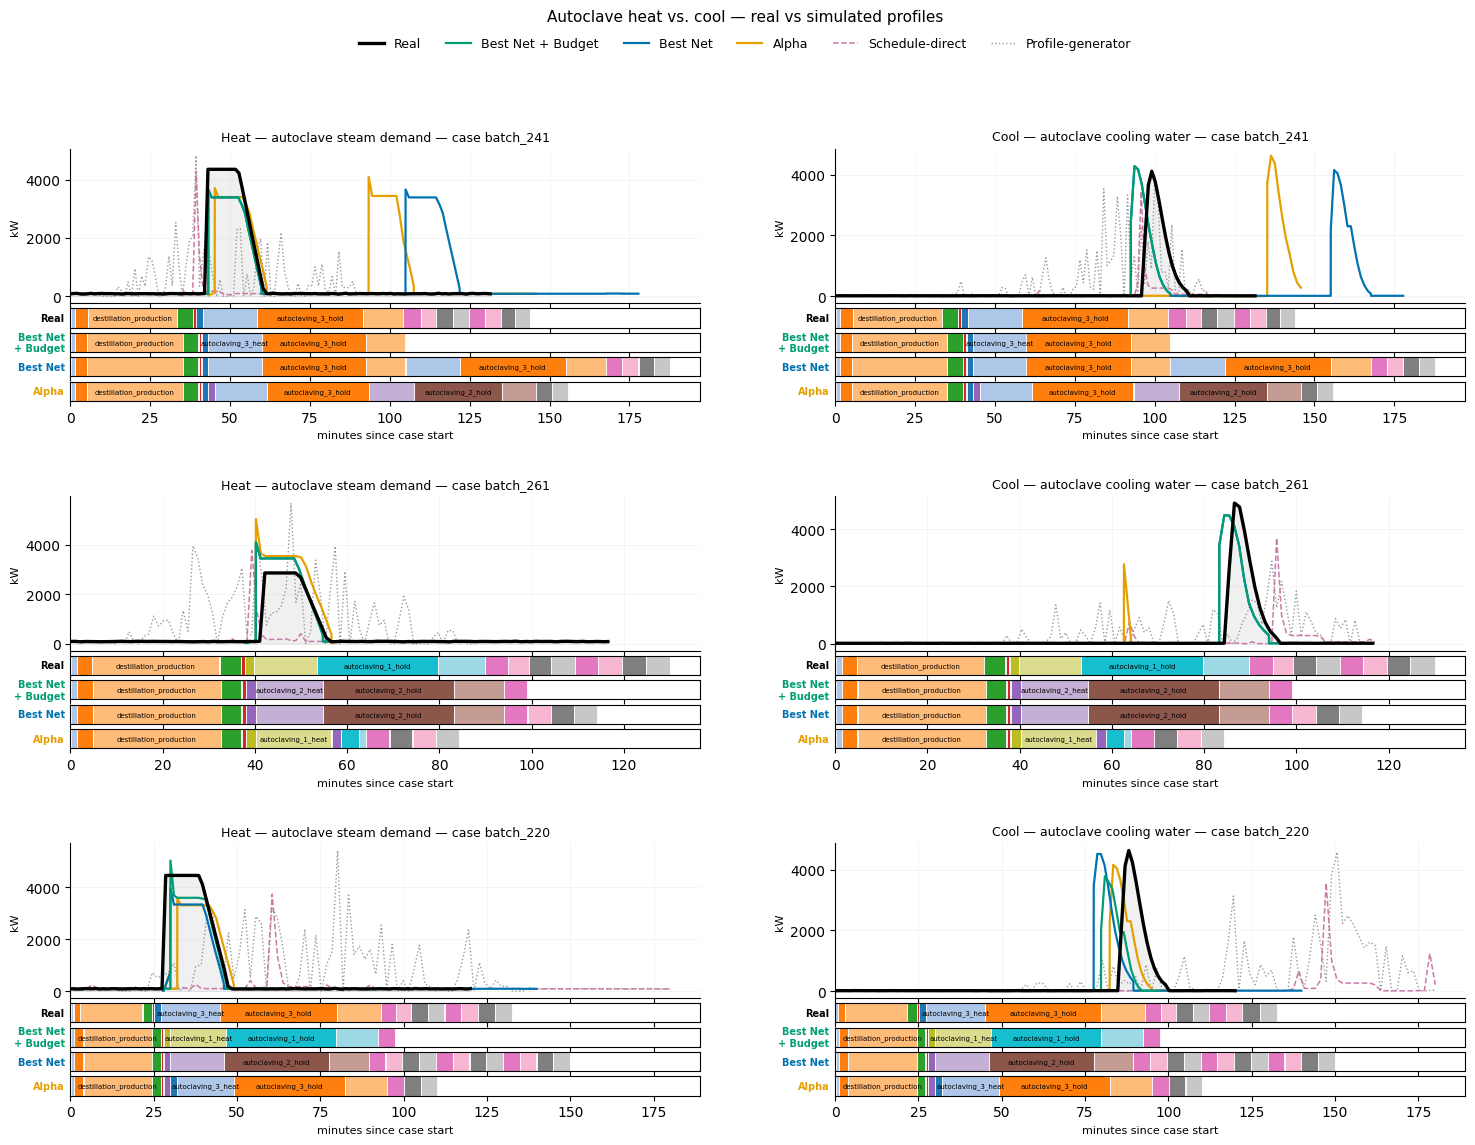

In [173]:
# -- Autoclave heat / cool side by side, one row per case ----------------------
# Exactly the per-sensor figure below (overlaid curves + one activity strip per
# log), just restricted to the two autoclave sensors and drawn next to each other
# in one figure: one column per sensor, one row block per case. All drawing
# helpers, styles and the activity colour map come from the overlay cell, so the
# panels here are identical to the per-sensor figures -- nothing is re-styled
# locally. No mean-kW bar panel: the two sensors sit directly side by side.
PAIR_SENSORS = ['autoclave_steam_demand_kW_energy_to_model',
                'autoclave_cooling_water_demand_kW_energy_to_model']
PAIR_TITLES  = {'autoclave_steam_demand_kW_energy_to_model':         'Heat — autoclave steam demand',
                'autoclave_cooling_water_demand_kW_energy_to_model': 'Cool — autoclave cooling water'}
PAIR_N_CASES = 3          # rows; taken from example_cases unless PAIR_CASES is set
PAIR_CASES   = None       # e.g. ['batch_294', 'batch_217', 'batch_272']
PAIR_SHARE_Y = False      # True = same kW scale for a sensor across all cases
PAIR_GUTTER  = 0.9        # empty column between the two sensors, relative to a
                          # curve column (7) -- lower = the two sit closer, but
                          # the right block's strip labels are written into it
PAIR_PDF     = f'visuals/predicted_vs_real_autoclave_heat_cool_{PROCESS}.pdf'

_pair_cases   = list(PAIR_CASES or example_cases)[:PAIR_N_CASES]
_pair_sensors = [s for s in PAIR_SENSORS if s in set(df_curves['sensor'])]
if len(_pair_sensors) < len(PAIR_SENSORS):
    print('missing from this run:', [s for s in PAIR_SENSORS if s not in _pair_sensors])

# Same strips, same order as the overlay figure: real schedule first, then the
# schedule each net actually simulated.
_pair_methods = [s for s in SERIES_TO_SHOW if s != 'Real']
_strips = ([('Real', df_real_log, 'black')]
           + [(m, sim_logs[m], _series_style[m]['color'])
              for m in _pair_methods if m in sim_logs])

# -- Geometry: rows exactly as in the overlay figure, one column per sensor ----
_n = len(_pair_cases)
_height_ratios, _row_start = [], []
for i in range(_n):
    _row_start.append(len(_height_ratios))
    _height_ratios += [4] + [0.5] * len(_strips)      # strips: thin bands
    if i < _n - 1:
        _height_ratios.append(2.2)                    # spacer between cases

_ns = len(_pair_sensors)
_width_ratios, _col_start = [], []
for j in range(_ns):
    _col_start.append(len(_width_ratios))
    _width_ratios += [7]                              # curves only
    if j < _ns - 1:
        _width_ratios.append(PAIR_GUTTER)             # gutter between sensors

fig = plt.figure(figsize=(9.0 * _ns, (2.9 + 0.3 * len(_strips)) * _n))
gs = fig.add_gridspec(len(_height_ratios), len(_width_ratios),
                      height_ratios=_height_ratios, width_ratios=_width_ratios,
                      hspace=0.1, wspace=0.06)

_present = [s for s in SERIES_TO_SHOW
            if s in set(df_curves[df_curves['sensor'].isin(_pair_sensors)]['series'])]
handles = [Line2D([0], [0], label=s, **_series_style[s]) for s in _present]

_first_curve = {}          # sensor -> first curve axes, for optional shared y
for j, sensor in enumerate(_pair_sensors):
    sub_sensor = df_curves[df_curves['sensor'] == sensor]
    c_curve = _col_start[j]
    for i, cid in enumerate(_pair_cases):
        r0 = _row_start[i]
        ax_curve = fig.add_subplot(gs[r0, c_curve],
                                   sharey=_first_curve.get(sensor) if PAIR_SHARE_Y else None)
        _first_curve.setdefault(sensor, ax_curve)
        ax_strips = [fig.add_subplot(gs[r0 + 1 + k, c_curve], sharex=ax_curve)
                     for k in range(len(_strips))]

        sub = sub_sensor[sub_sensor['case_id'] == cid]
        _title = f'{PAIR_TITLES.get(sensor, sensor)} — case {cid}'
        if sub.empty:
            ax_curve.set_title(f'{_title} — no data for this sensor', fontsize=9)
        else:
            _draw_series(ax_curve, sub, SERIES_TO_SHOW)
            ax_curve.set_title(_title, fontsize=9)
        ax_curve.set_ylabel('kW', fontsize=8)
        _clean(ax_curve)
        plt.setp(ax_curve.get_xticklabels(), visible=False)

        for k, ((_lbl, _log, _col), ax_s) in enumerate(zip(_strips, ax_strips)):
            _draw_activity_strip(ax_s, _activity_timeline(_log, cid))
            # Repeated next to EVERY gantt, right block included, and written in
            # that series' own legend colour -- so a strip can be tied to its
            # curve without counting rows back to the left block.
            ax_s.set_ylabel(_lbl.replace(' + ', '\n+ '), rotation=0, ha='right',
                            va='center', fontsize=7, color=_col, fontweight='bold')
            if k < len(_strips) - 1:
                plt.setp(ax_s.get_xticklabels(), visible=False)
            else:
                ax_s.set_xlabel('minutes since case start', fontsize=8)

_top = 1 - 0.55 / fig.get_figheight()      # ~0.55in reserved, whatever the height
fig.tight_layout(rect=[0, 0, 1, _top])
if handles:
    fig.legend(handles=handles, labels=[h.get_label() for h in handles],
               loc='upper center', bbox_to_anchor=(0.5, _top + 0.30 / fig.get_figheight()),
               ncol=len(handles), fontsize=9, frameon=False)
fig.suptitle('Autoclave heat vs. cool — real vs simulated profiles', fontsize=11,
             y=1 - 0.08 / fig.get_figheight())

Path(PAIR_PDF).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PAIR_PDF, format='pdf', bbox_inches='tight', dpi=300, facecolor='white')
print(f'Saved visual to: {PAIR_PDF}')
plt.show()
